# SSU debugging

In [20]:
import os
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from figutils import cm, set_figure_style

set_figure_style()

ROOT = ".."
DATA_DIR = os.path.join(ROOT, "data/raw/ENA/sf3b1mut/STAR")
EVAL_DIR = os.path.join(ROOT, "results/bsc/evaluation/alphagenome_pytorch/full")
RUN = "randinit__newloss__annotated__frozen__multigpu_ddp__alpha5"
EPOCH = 10

OUTPUT_DIR = os.path.join("pdfs", "debug_ssu")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Section 1: Replicate-replicate SSU correlation

In [39]:
# WT biological replicates with SSU parquets
SAMPLES_META = {
    "SRR17111301": "WT rep1 (run A)",
    "SRR17111303": "WT rep1 (run B)",
    "SRR17111304": "WT rep2",
    "SRR17111307": "WT rep3",
}

ssu_reps = {}
for sample, label in SAMPLES_META.items():
    df = pd.read_parquet(
        os.path.join(DATA_DIR, sample, "paper_pass.ssu.parquet"),
        columns=["chrom", "strand", "role", "exon_pos", "alpha_juncs", "ssu_spliser"],
    )
    df = df[df["chrom"].str.startswith("chr") & ~df["chrom"].str.contains("_")]
    ssu_reps[sample] = df.rename(columns={"ssu_spliser": sample, "alpha_juncs": "alpha_" + sample})

# Merge all on shared site key
KEY = ["chrom", "strand", "role", "exon_pos"]
merged = ssu_reps["SRR17111301"][["chrom","strand","role","exon_pos","SRR17111301"]]
for sample in ["SRR17111303", "SRR17111304", "SRR17111307"]:
    merged = merged.merge(ssu_reps[sample][["chrom","strand","role","exon_pos", sample]], on=KEY, how="inner")

print("Sites in all 4 WT replicates:", len(merged))
merged.head(3)

Sites in all 4 WT replicates: 277008


,chrom,strand,role,exon_pos,SRR17111301,SRR17111303,SRR17111304,SRR17111307
0,chr1,-,donor,14829,0.892857,0.961538,0.953488,0.957447
1,chr1,-,donor,15038,1.000000,0.785714,0.600000,0.875000
2,chr1,-,donor,16765,1.000000,1.000000,0.978261,0.914286


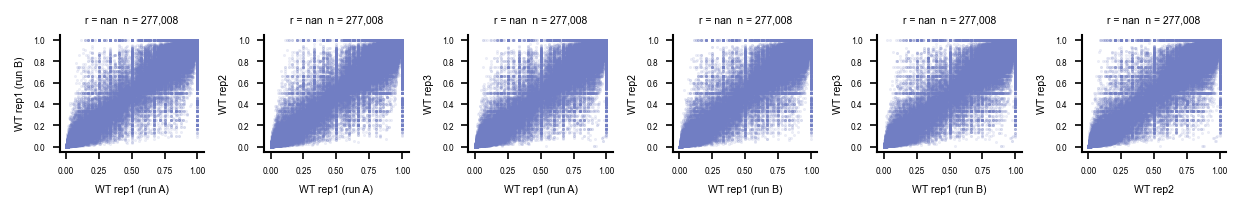

In [40]:
samples = list(SAMPLES_META.keys())
pairs = list(itertools.combinations(samples, 2))
n = len(pairs)

fig, axes = plt.subplots(1, n, figsize=(n * 3.5 * cm, 3.5 * cm), sharey=False)

for ax, (s1, s2) in zip(axes, pairs):
    x = merged[s1].values
    y = merged[s2].values
    r, _ = pearsonr(x, y)
    ax.scatter(x, y, s=0.2, alpha=0.15, rasterized=True, color="#717EC3")
    ax.set_xlabel(SAMPLES_META[s1], fontsize=5)
    ax.set_ylabel(SAMPLES_META[s2], fontsize=5)
    ax.set_title("r = {:.3f}  n = {:,}".format(r, len(x)), fontsize=5)
    ax.tick_params(labelsize=4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "replicate_ssu_correlation.pdf"), bbox_inches="tight")
plt.show()

In [41]:
# Summary table
rows = []
for s1, s2 in pairs:
    r, _ = pearsonr(merged[s1], merged[s2])
    rows.append({"sample_A": SAMPLES_META[s1], "sample_B": SAMPLES_META[s2], "pearson_r": round(r, 4), "n_sites": len(merged)})
pd.DataFrame(rows)

,sample_A,sample_B,pearson_r,n_sites
0,WT rep1 (run A),WT rep1 (run B),NaN,277008
1,WT rep1 (run A),WT rep2,NaN,277008
2,WT rep1 (run A),WT rep3,NaN,277008
3,WT rep1 (run B),WT rep2,NaN,277008
4,WT rep1 (run B),WT rep3,NaN,277008
5,WT rep2,WT rep3,NaN,277008


## Section 3: SSU prediction quality decomposed by read depth

In [42]:
preds = pd.read_parquet(
    os.path.join(EVAL_DIR, RUN, "epoch{}".format(EPOCH), "test", "predictions", "ssu_scores.parquet")
)

# Add alpha_juncs from raw SSU parquets (training samples only)
TRAIN_SAMPLES = ["SRR17111303", "SRR17111311"]
raw_parts = []
for sample in TRAIN_SAMPLES:
    df = pd.read_parquet(
        os.path.join(DATA_DIR, sample, "paper_pass.ssu.parquet"),
        columns=["chrom", "strand", "role", "exon_pos", "alpha_juncs"],
    ).assign(sample_id=sample).rename(columns={"exon_pos": "exon_pos_1based"})
    raw_parts.append(df)
raw = pd.concat(raw_parts, ignore_index=True)

preds = preds.merge(raw, on=["chrom", "strand", "role", "exon_pos_1based", "sample_id"], how="left")
print("alpha_juncs fill rate: {:.1%}".format(preds["alpha_juncs"].notna().mean()))
preds.head(3)

alpha_juncs fill rate: 100.0%


,chrom,exon_pos_1based,strand,role,sample_id,pred_ssu,obs_ssu,alpha_juncs
0,chr20,7977624,-,donor,SRR17111303,0.000060,0.051282,1
1,chr20,7982621,-,donor,SRR17111303,0.031738,0.992754,115
2,chr20,7983857,-,donor,SRR17111303,0.055908,1.000000,79


In [43]:
DEPTH_BINS = [1, 3, 6, 21, 101, np.inf]
DEPTH_LABELS = ["1-2", "3-5", "6-20", "21-100", "101+"]

preds["depth_bin"] = pd.cut(
    preds["alpha_juncs"],
    bins=DEPTH_BINS,
    labels=DEPTH_LABELS,
    right=False,
)

print(preds.groupby("depth_bin", observed=True).size().rename("n_sites"))

depth_bin
1-2       507317
3-5       151424
6-20      221449
21-100    376580
101+      435915
Name: n_sites, dtype: int64


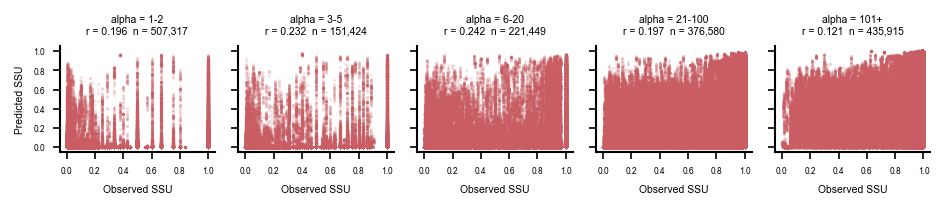

In [44]:
n_bins = len(DEPTH_LABELS)
fig, axes = plt.subplots(1, n_bins, figsize=(n_bins * 3.2 * cm, 3.5 * cm), sharey=True, sharex=True)

for ax, label in zip(axes, DEPTH_LABELS):
    sub = preds[preds["depth_bin"] == label].dropna(subset=["pred_ssu", "obs_ssu"])
    if len(sub) < 2:
        ax.set_title(label, fontsize=5)
        continue
    r, _ = pearsonr(sub["obs_ssu"], sub["pred_ssu"])
    ax.scatter(sub["obs_ssu"], sub["pred_ssu"], s=0.3, alpha=0.15, rasterized=True, color="#C95D63")
    ax.set_title("alpha = {}\nr = {:.3f}  n = {:,}".format(label, r, len(sub)), fontsize=5)
    ax.set_xlabel("Observed SSU", fontsize=5)
    ax.tick_params(labelsize=4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    sns.despine(ax=ax)

axes[0].set_ylabel("Predicted SSU", fontsize=5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ssu_pred_vs_obs_by_depth.pdf"), bbox_inches="tight")
plt.show()

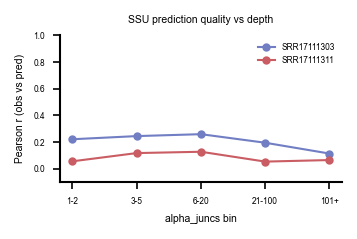

depth_bin   sample_id  pearson_r      n
      1-2 SRR17111303     0.2211 236120
      1-2 SRR17111311     0.0557 271197
      3-5 SRR17111303     0.2447  71407
      3-5 SRR17111311     0.1174  80017
     6-20 SRR17111303     0.2591 106332
     6-20 SRR17111311     0.1273 115117
   21-100 SRR17111303     0.1949 190522
   21-100 SRR17111311     0.0535 186058
     101+ SRR17111303     0.1138 209277
     101+ SRR17111311     0.0651 226638


In [ ]:
# Pearson r per depth bin, per sample
rows = []
for (bin_label, sample), grp in preds.dropna(subset=["pred_ssu","obs_ssu","depth_bin"]).groupby(["depth_bin","sample_id"], observed=True):
    if len(grp) < 5:
        continue
    r, _ = pearsonr(grp["obs_ssu"], grp["pred_ssu"])
    rows.append({"depth_bin": bin_label, "sample_id": sample, "pearson_r": round(r, 4), "n": len(grp)})
summary = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6 * cm, 4 * cm))
pal = {"SRR17111303": "#717EC3", "SRR17111311": "#C95D63"}
for sample, grp in summary.groupby("sample_id"):
    ax.plot(grp["depth_bin"].astype(str), grp["pearson_r"], marker="o", markersize=3,
            linewidth=1, color=pal[sample], label=sample)
ax.set_xlabel("alpha_juncs bin", fontsize=5)
ax.set_ylabel("Pearson r (obs vs pred)", fontsize=5)
ax.set_title("SSU prediction quality vs depth", fontsize=5)
ax.tick_params(labelsize=4)
ax.legend(fontsize=4, frameon=False)
ax.set_ylim(-0.1, 1.0)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ssu_pearsonr_by_depth.pdf"), bbox_inches="tight")
plt.show()
print(summary.to_string(index=False))

## Section 2: SSU head weight distributions — pretrained vs finetuned

In [28]:
import torch
from safetensors.torch import load_file

PRETRAINED_WEIGHTS = os.path.join(ROOT, "data/raw/articles/Avsec2026/alphagenome_pytorch/fold-1/model_fold_1.safetensors")
CHECKPOINT = os.path.join(ROOT, "results/bsc/finetuning/alphagenome_pytorch/full/randinit__newloss__annotated__frozen__multigpu_ddp/checkpoint_epoch5.pth")

pt_state = load_file(PRETRAINED_WEIGHTS)
ft_state = torch.load(CHECKPOINT, map_location="cpu")["model_state_dict"]

# shape: [strands, n_tracks, 1536] -> flatten strands dim -> [n_tracks_total, 1536]
pt_w = pt_state["splice_sites_usage_head.conv.weight"].float().reshape(-1, 1536).numpy()
ft_w = ft_state["splice_sites_usage_head.conv.weight"].float().reshape(-1, 1536).numpy()

pt_b = pt_state["splice_sites_usage_head.conv.bias"].float().reshape(-1).numpy()
ft_b = ft_state["splice_sites_usage_head.conv.bias"].float().reshape(-1).numpy()

rows = []
for label, w, b in [("pretrained", pt_w, pt_b), ("finetuned", ft_w, ft_b)]:
    for i in range(w.shape[0]):
        rows.append({"model": label, "channel": i, "weight_mean": w[i].mean(), "weight_std": w[i].std(), "bias": b[i]})
df_weights = pd.DataFrame(rows)

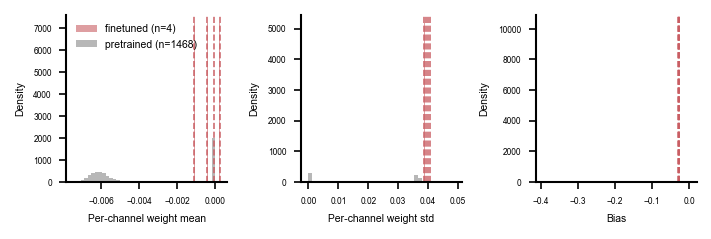

In [29]:
PAL_MODEL = {"pretrained": "#888888", "finetuned": "#C95D63"}

fig, axes = plt.subplots(1, 3, figsize=(12 * cm, 4 * cm))

for ax, col, xlabel in zip(
    axes,
    ["weight_mean", "weight_std", "bias"],
    ["Per-channel weight mean", "Per-channel weight std", "Bias"],
):
    for model, grp in df_weights.groupby("model"):
        ax.hist(
            grp[col],
            bins=40,
            color=PAL_MODEL[model],
            alpha=0.6,
            label="{} (n={})".format(model, len(grp)),
            density=True,
        )
        if model == "finetuned":
            for v in grp[col]:
                ax.axvline(v, color=PAL_MODEL[model], linewidth=0.8, linestyle="--", alpha=0.9)
    ax.set_xlabel(xlabel, fontsize=5)
    ax.set_ylabel("Density", fontsize=5)
    ax.tick_params(labelsize=4)
    sns.despine(ax=ax)

axes[0].legend(fontsize=5, frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ssu_head_weight_distributions.pdf"), bbox_inches="tight")
plt.show()

## Section 5: Our K562 SSU vs AlphaGenome pretraining SSU

Checks whether the SSU we compute from ENCODE ENCSR000AEM (K562 polyA+ RNA-seq) matches the
values AlphaGenome was actually trained on.

**Sources**
- **Pretrained**: `k562_ssu_merged.parquet` extracted from `SPLICE_SITE_USAGE` TFRecords (VALID + TEST subsets).  
  Columns `ssu_pos_strand` / `ssu_neg_strand`, positions 0-based → `exon_pos = pos + 1` to match pipeline.
- **Pipeline**: `paper_pass.ssu.parquet` for each K562 replicate from `k562.smk` (ENCSR000AEM, the correct experiment identified via ENCFF132DVY → ENCSR000AEM ENCODE API lookup).  
  Column `ssu_approx`, `exon_pos` 1-based.

In [30]:
K562_DIR     = os.path.join(ROOT, "data/raw/ENCODE/k562/STAR")
# ENCSR000AEM: the experiment AlphaGenome used for K562 polyA+ SSU (file ENCFF132DVY)
K562_SAMPLES = {"ENCSR000AEM_rep1": "K562 rep1", "ENCSR000AEM_rep2": "K562 rep2"}

# AlphaGenome pretraining SSU — merged across VALID + TEST subsets
PRETRAIN_SSU_PATH = os.path.join(
    ROOT,
    "data/raw/articles/Avsec2026/alphagenome_jax",
    "k562_ssu_merged.parquet",
)

# Load pretrained SSU and pivot to long format (one row per site × strand)
pt = pd.read_parquet(PRETRAIN_SSU_PATH)
print("Subsets in merged parquet:", pt["subset"].unique())
pt_long = pd.concat([
    pt[["chrom", "pos", "ssu_pos_strand"]].rename(columns={"ssu_pos_strand": "ssu_pretrain"}).assign(strand="+"),
    pt[["chrom", "pos", "ssu_neg_strand"]].rename(columns={"ssu_neg_strand": "ssu_pretrain"}).assign(strand="-"),
], ignore_index=True)
pt_long = pt_long[pt_long["ssu_pretrain"] > 0].copy()
# TFRecord positions are 0-based; exon_pos in our parquet is 1-based
pt_long["exon_pos"] = pt_long["pos"] + 1
pt_long = pt_long.drop(columns="pos")
print("Pretrained non-zero sites:", len(pt_long))

# Load pipeline K562 SSU for each replicate
KEY = ["chrom", "strand", "exon_pos"]
pipe_parts = []
for sample, label in K562_SAMPLES.items():
    df = pd.read_parquet(
        os.path.join(K562_DIR, sample, "paper_pass.ssu.parquet"),
        columns=["chrom", "strand", "exon_pos", "alpha_juncs", "ssu_spliser"],
    ).rename(columns={"ssu_spliser": "ssu_pipeline"}).assign(sample=label)
    pipe_parts.append(df)
pipe = pd.concat(pipe_parts, ignore_index=True)
print("Pipeline sites (both reps):", len(pipe))

# Inner join on chrom + strand + exon_pos
merged5 = pipe.merge(pt_long[KEY + ["ssu_pretrain"]], on=KEY, how="inner")
print("Shared sites:", len(merged5))
merged5.head(3)

Subsets in merged parquet: <ArrowStringArray>
['VALID']
Length: 1, dtype: str
Pretrained non-zero sites: 38287
Pipeline sites (both reps): 679328


Shared sites: 53560


,chrom,strand,exon_pos,alpha_juncs,ssu_pipeline,sample,ssu_pretrain
0,chr11,-,26561225,19,1.0,K562 rep1,0.812500
1,chr11,-,27151152,12,1.0,K562 rep1,0.952148
2,chr11,-,27216285,1,0.5,K562 rep1,0.086975


In [31]:
# --- diagnostic: how many pretrained positions have any pipeline data nearby? ---
pipe_all = pd.concat(pipe_parts, ignore_index=True)

# build a set of (chrom, exon_pos) from all pipeline sites
pipe_pos_set = set(zip(pipe_all["chrom"], pipe_all["exon_pos"]))

# pretrained positions shifted to 1-based
pt_long_filt = pt_long[pt_long["chrom"].isin(pipe_all["chrom"].unique())].copy()
pt_long_filt["match_exact"] = [
    (c, p) in pipe_pos_set for c, p in zip(pt_long_filt["chrom"], pt_long_filt["exon_pos"])
]

# also check ±1 bp (accounts for any residual off-by-one)
pt_long_filt["match_pm1"] = [
    any((c, p+d) in pipe_pos_set for d in (-1, 0, 1))
    for c, p in zip(pt_long_filt["chrom"], pt_long_filt["exon_pos"])
]

print("Pretrained sites on shared chroms:       {:,}".format(len(pt_long_filt)))
print("Exact match in pipeline (pos+1==exon_pos): {:,}  ({:.2%})".format(
    pt_long_filt["match_exact"].sum(), pt_long_filt["match_exact"].mean()))
print("Match within ±1 bp:                        {:,}  ({:.2%})".format(
    pt_long_filt["match_pm1"].sum(), pt_long_filt["match_pm1"].mean()))

Pretrained sites on shared chroms:       38,287
Exact match in pipeline (pos+1==exon_pos): 29,773  (77.76%)
Match within ±1 bp:                        29,802  (77.84%)


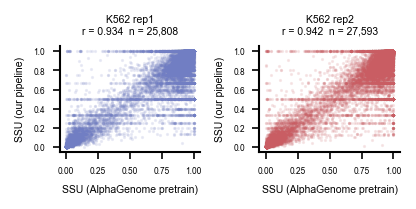

,sample,pearson_r,n
0,K562 rep1,0.9340,25808
1,K562 rep2,0.9422,27593


In [32]:
samples = list(K562_SAMPLES.values())
PAL_K562 = {"K562 rep1": "#717EC3", "K562 rep2": "#C95D63"}

fig, axes = plt.subplots(1, len(samples), figsize=(len(samples) * 3.5 * cm, 3.5 * cm))

rows_r = []
for ax, label in zip(axes, samples):
    sub = merged5[merged5["sample"] == label].dropna(subset=["ssu_pipeline", "ssu_pretrain"])
    r, _ = pearsonr(sub["ssu_pipeline"], sub["ssu_pretrain"])
    rows_r.append({"sample": label, "pearson_r": round(r, 4), "n": len(sub)})
    ax.scatter(sub["ssu_pretrain"], sub["ssu_pipeline"],
               s=0.3, alpha=0.15, rasterized=True, color=PAL_K562[label])
    ax.set_xlabel("SSU (AlphaGenome pretrain)", fontsize=5)
    ax.set_ylabel("SSU (our pipeline)", fontsize=5)
    ax.set_title("{}\nr = {:.3f}  n = {:,}".format(label, r, len(sub)), fontsize=5)
    ax.tick_params(labelsize=4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "k562_ssu_pretrain_vs_pipeline.pdf"), bbox_inches="tight")
plt.show()

pd.DataFrame(rows_r)

                 variant    sample  pearson_r     n
    ssu_approx\n(α/α+β2) K562 rep1     0.7874 25869
    ssu_approx\n(α/α+β2) K562 rep2     0.7920 27691
    ssu_b1only\n(α/α+β1) K562 rep1     0.7068 25808
    ssu_b1only\n(α/α+β1) K562 rep2     0.7514 27593
ssu_spliser\n(α/α+β1+β2) K562 rep1     0.9340 25808
ssu_spliser\n(α/α+β1+β2) K562 rep2     0.9422 27593


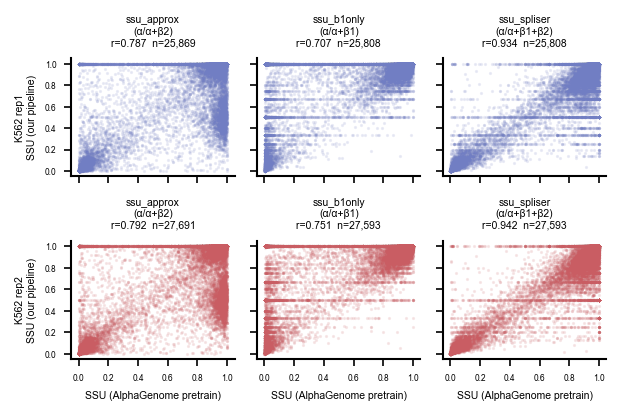

In [33]:
# Compare SSU variants vs pretrained to identify which denominator AlphaGenome uses
# ssu_approx  = alpha / (alpha + beta2)         junction-only
# ssu_b1only  = alpha / (alpha + beta1)         read-through only
# ssu_spliser = alpha / (alpha + beta1 + beta2) full SpliSER

pipe_full_parts = []
for sample, label in K562_SAMPLES.items():
    df = pd.read_parquet(
        os.path.join(K562_DIR, sample, "paper_pass.ssu.parquet"),
        columns=["chrom", "strand", "exon_pos",
                 "alpha_juncs", "beta2_juncs",
                 "alpha_bam", "beta1_bam", "beta2_bam",
                 "ssu_approx", "ssu_spliser"],
    ).assign(sample=label)
    denom_b1 = df["alpha_bam"] + df["beta1_bam"]
    df["ssu_b1only"] = (df["alpha_bam"] / denom_b1).where(denom_b1 > 0)
    pipe_full_parts.append(df)
pipe_full = pd.concat(pipe_full_parts, ignore_index=True)

merged_full = pipe_full.merge(pt_long[KEY + ["ssu_pretrain"]], on=KEY, how="inner")

variants = {
    "ssu_approx\n(α/α+β2)":  "ssu_approx",
    "ssu_b1only\n(α/α+β1)":  "ssu_b1only",
    "ssu_spliser\n(α/α+β1+β2)": "ssu_spliser",
}

rows_cmp = []
for label, col in variants.items():
    for sample in K562_SAMPLES.values():
        sub = merged_full[merged_full["sample"] == sample].dropna(subset=[col, "ssu_pretrain"])
        r, _ = pearsonr(sub[col], sub["ssu_pretrain"])
        rows_cmp.append({"variant": label, "sample": sample, "pearson_r": round(r, 4), "n": len(sub)})

df_cmp = pd.DataFrame(rows_cmp)
print(df_cmp.to_string(index=False))

# Scatter panel: one column per variant, one row per replicate
n_variants = len(variants)
n_samples  = len(K562_SAMPLES)
fig, axes = plt.subplots(n_samples, n_variants,
                         figsize=(n_variants * 3.5 * cm, n_samples * 3.5 * cm),
                         sharex=True, sharey=True)

for row_i, sample in enumerate(K562_SAMPLES.values()):
    sub = merged_full[merged_full["sample"] == sample]
    for col_j, (label, col) in enumerate(variants.items()):
        ax = axes[row_i, col_j]
        valid = sub.dropna(subset=[col, "ssu_pretrain"])
        r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
        ax.scatter(valid["ssu_pretrain"], valid[col],
                   s=0.3, alpha=0.15, rasterized=True, color=PAL_K562[sample])
        ax.set_title("{}\nr={:.3f}  n={:,}".format(label, r, len(valid)), fontsize=5)
        ax.tick_params(labelsize=4)
        if col_j == 0:
            ax.set_ylabel("{}\nSSU (our pipeline)".format(sample), fontsize=5)
        if row_i == n_samples - 1:
            ax.set_xlabel("SSU (AlphaGenome pretrain)", fontsize=5)
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "k562_ssu_variant_comparison.pdf"), bbox_inches="tight")
plt.show()

Merged-replicate sites matching pretrained: 29,773
                 variant      sample  pearson_r     n
    ssu_approx\n(α/α+β2)   K562 rep1     0.7874 25869
    ssu_approx\n(α/α+β2)   K562 rep2     0.7920 27691
    ssu_b1only\n(α/α+β1)   K562 rep1     0.7068 25808
    ssu_b1only\n(α/α+β1)   K562 rep2     0.7514 27593
ssu_spliser\n(α/α+β1+β2)   K562 rep1     0.9340 25808
ssu_spliser\n(α/α+β1+β2)   K562 rep2     0.9422 27593
    ssu_approx\n(α/α+β2) merged reps     0.8185 29773
    ssu_b1only\n(α/α+β1) merged reps     0.7409 29681
ssu_spliser\n(α/α+β1+β2) merged reps     0.9471 29681


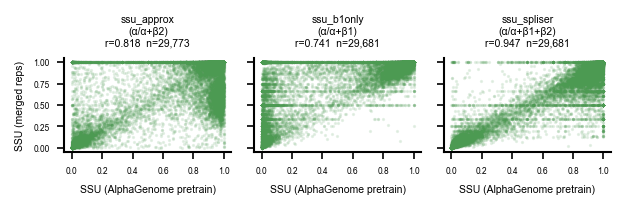

In [34]:
# Merge replicates by summing raw counts, then recompute SSU variants
# This mirrors how AlphaGenome likely combines replicates before computing targets.

COUNT_COLS = ["alpha_juncs", "beta2_juncs", "alpha_bam", "beta1_bam", "beta2_bam"]
merged_rep = (
    pipe_full
    .groupby(KEY, as_index=False)[COUNT_COLS]
    .sum()
)

# Recompute SSU variants from summed counts
denom_approx  = merged_rep["alpha_juncs"] + merged_rep["beta2_juncs"]
denom_b1only  = merged_rep["alpha_bam"]   + merged_rep["beta1_bam"]
denom_spliser = merged_rep["alpha_bam"]   + merged_rep["beta1_bam"] + merged_rep["beta2_bam"]

merged_rep["ssu_approx"]  = (merged_rep["alpha_juncs"] / denom_approx ).where(denom_approx  > 0)
merged_rep["ssu_b1only"]  = (merged_rep["alpha_bam"]   / denom_b1only ).where(denom_b1only  > 0)
merged_rep["ssu_spliser"] = (merged_rep["alpha_bam"]   / denom_spliser).where(denom_spliser > 0)

merged_rep_pt = merged_rep.merge(pt_long[KEY + ["ssu_pretrain"]], on=KEY, how="inner")
print("Merged-replicate sites matching pretrained: {:,}".format(len(merged_rep_pt)))

# Correlation table
rows_rep = []
for label, col in variants.items():
    valid = merged_rep_pt.dropna(subset=[col, "ssu_pretrain"])
    r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
    rows_rep.append({"variant": label, "sample": "merged reps", "pearson_r": round(r, 4), "n": len(valid)})

df_rep = pd.DataFrame(rows_rep)
print(pd.concat([df_cmp, df_rep], ignore_index=True).to_string(index=False))

# Scatter panel: merged replicate only
fig, axes = plt.subplots(1, n_variants, figsize=(n_variants * 3.5 * cm, 3.5 * cm),
                         sharex=True, sharey=True)

for ax, (label, col) in zip(axes, variants.items()):
    valid = merged_rep_pt.dropna(subset=[col, "ssu_pretrain"])
    r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
    ax.scatter(valid["ssu_pretrain"], valid[col],
               s=0.3, alpha=0.15, rasterized=True, color="#4C9A52")
    ax.set_title("{}\nr={:.3f}  n={:,}".format(label, r, len(valid)), fontsize=5)
    ax.set_xlabel("SSU (AlphaGenome pretrain)", fontsize=5)
    ax.tick_params(labelsize=4)
    sns.despine(ax=ax)

axes[0].set_ylabel("SSU (merged reps)", fontsize=5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "k562_ssu_merged_reps_comparison.pdf"), bbox_inches="tight")
plt.show()

SSU=1.0 line: 4,736 sites
  alpha_bam percentiles: {'count': 4736.0, 'mean': 29.48754222972973, 'std': 49.578049067221656, 'min': 1.0, '10%': 1.0, '25%': 2.0, '50%': 11.0, '75%': 36.0, '90%': 77.0, 'max': 594.0}
  beta1_bam percentiles: {'count': 4736.0, 'mean': 0.0, 'std': 0.0, 'min': 0.0, '50%': 0.0, 'max': 0.0}
  beta2_bam percentiles: {'count': 4736.0, 'mean': 0.0, 'std': 0.0, 'min': 0.0, '50%': 0.0, 'max': 0.0}
  pretrain SSU: mean=0.950 std=0.119

SSU=0.5 line: 581 sites
  alpha_bam percentiles: {'count': 581.0, 'mean': 3.1755593803786577, 'std': 12.779299866365337, 'min': 1.0, '10%': 1.0, '25%': 1.0, '50%': 1.0, '75%': 2.0, '90%': 6.0, 'max': 281.0}
  beta1_bam percentiles: {'count': 581.0, 'mean': 0.8777969018932874, 'std': 4.4610041354622245, 'min': 0.0, '50%': 0.0, 'max': 78.0}
  beta2_bam percentiles: {'count': 581.0, 'mean': 2.29776247848537, 'std': 11.305437133431372, 'min': 0.0, '50%': 1.0, 'max': 268.0}
  pretrain SSU: mean=0.735 std=0.284



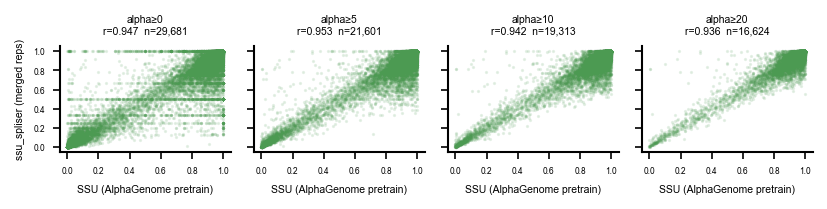

In [35]:
# Diagnose horizontal lines at SSU=0.5 and SSU=1.0 in ssu_spliser
# Caused by low read counts (discretization): alpha=1,beta=1 → 0.5; alpha=1,beta=0 → 1.0

df_diag = merged_rep_pt.dropna(subset=["ssu_spliser", "ssu_pretrain"]).copy()
df_diag["ssu_spliser_round"] = df_diag["ssu_spliser"].round(4)

for ssu_val, label in [(1.0, "SSU=1.0 line"), (0.5, "SSU=0.5 line")]:
    line = df_diag[df_diag["ssu_spliser_round"] == ssu_val]
    print("{}: {:,} sites".format(label, len(line)))
    print("  alpha_bam percentiles: {}".format(
        line["alpha_bam"].describe(percentiles=[.1,.25,.5,.75,.9]).to_dict()))
    print("  beta1_bam percentiles: {}".format(
        line["beta1_bam"].describe(percentiles=[.5]).to_dict()))
    print("  beta2_bam percentiles: {}".format(
        line["beta2_bam"].describe(percentiles=[.5]).to_dict()))
    print("  pretrain SSU: mean={:.3f} std={:.3f}".format(
        line["ssu_pretrain"].mean(), line["ssu_pretrain"].std()))
    print()

# Re-plot ssu_spliser by minimum alpha_bam depth threshold
ALPHA_THRESHOLDS = [0, 5, 10, 20]
fig, axes = plt.subplots(1, len(ALPHA_THRESHOLDS),
                         figsize=(len(ALPHA_THRESHOLDS) * 3.5 * cm, 3.5 * cm),
                         sharex=True, sharey=True)

for ax, min_alpha in zip(axes, ALPHA_THRESHOLDS):
    sub = df_diag[df_diag["alpha_bam"] >= min_alpha]
    r, _ = pearsonr(sub["ssu_spliser"], sub["ssu_pretrain"])
    ax.scatter(sub["ssu_pretrain"], sub["ssu_spliser"],
               s=0.3, alpha=0.15, rasterized=True, color="#4C9A52")
    ax.set_title("alpha≥{}\nr={:.3f}  n={:,}".format(min_alpha, r, len(sub)), fontsize=5)
    ax.set_xlabel("SSU (AlphaGenome pretrain)", fontsize=5)
    ax.tick_params(labelsize=4)
    sns.despine(ax=ax)

axes[0].set_ylabel("ssu_spliser (merged reps)", fontsize=5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "k562_ssu_spliser_by_depth.pdf"), bbox_inches="tight")
plt.show()

Averaged-replicate sites matching pretrained: 29,773
                 variant aggregation  pearson_r     n
    ssu_approx\n(α/α+β2)    mean SSU     0.8281 29773
    ssu_approx\n(α/α+β2)  sum counts     0.8185 29773
    ssu_b1only\n(α/α+β1)    mean SSU     0.7357 29681
    ssu_b1only\n(α/α+β1)  sum counts     0.7409 29681
ssu_spliser\n(α/α+β1+β2)    mean SSU     0.9465 29681
ssu_spliser\n(α/α+β1+β2)  sum counts     0.9471 29681


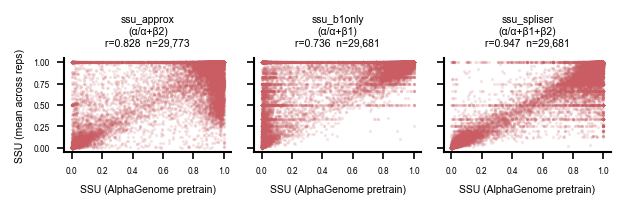

In [36]:
# Average per-sample SSU across replicates (AlphaGenome method: compute SSU independently then aggregate)
ssu_cols = list(variants.values())  # ssu_approx, ssu_b1only, ssu_spliser

avg_rep = (
    pipe_full
    .groupby(KEY, as_index=False)[ssu_cols]
    .mean()
)

avg_rep_pt = avg_rep.merge(pt_long[KEY + ["ssu_pretrain"]], on=KEY, how="inner")
print("Averaged-replicate sites matching pretrained: {:,}".format(len(avg_rep_pt)))

rows_avg = []
for label, col in variants.items():
    valid = avg_rep_pt.dropna(subset=[col, "ssu_pretrain"])
    r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
    rows_avg.append({"variant": label, "aggregation": "mean SSU", "pearson_r": round(r, 4), "n": len(valid)})

# Compare all aggregation strategies side by side
rows_sum = []
for label, col in variants.items():
    valid = merged_rep_pt.dropna(subset=[col, "ssu_pretrain"])
    r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
    rows_sum.append({"variant": label, "aggregation": "sum counts", "pearson_r": round(r, 4), "n": len(valid)})

df_agg = pd.DataFrame(rows_avg + rows_sum).sort_values(["variant", "aggregation"])
print(df_agg.to_string(index=False))

# Scatter: averaged ssu_spliser
fig, axes = plt.subplots(1, n_variants, figsize=(n_variants * 3.5 * cm, 3.5 * cm),
                         sharex=True, sharey=True)
for ax, (label, col) in zip(axes, variants.items()):
    valid = avg_rep_pt.dropna(subset=[col, "ssu_pretrain"])
    r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
    ax.scatter(valid["ssu_pretrain"], valid[col],
               s=0.3, alpha=0.15, rasterized=True, color="#C95D63")
    ax.set_title("{}\nr={:.3f}  n={:,}".format(label, r, len(valid)), fontsize=5)
    ax.set_xlabel("SSU (AlphaGenome pretrain)", fontsize=5)
    ax.tick_params(labelsize=4)
    sns.despine(ax=ax)

axes[0].set_ylabel("SSU (mean across reps)", fontsize=5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "k562_ssu_mean_reps_comparison.pdf"), bbox_inches="tight")
plt.show()

## Section 6: Strand-agnostic SSU (ssu_ag) vs AlphaGenome pretrained

`ssu_ag = alpha_ag / (alpha_ag + beta1_ag)` where both counts are computed across **all reads
regardless of strand**, directly implementing AlphaGenome's stated method.  Compares all four
variants (approx, b1only, spliser, ag) on merged replicates (counts summed before SSU computation).

Sites (strand-specific ssu_spliser):    389,163
Sites (unstranded ssu_nostr):           389,163
Extra nostr sites not in spliser:       0

Merged-replicate sites matching pretrained: 29,773
           variant  pearson_r     n
        ssu_approx     0.8185 29773
        ssu_b1only     0.7409 29681
       ssu_spliser     0.9471 29681
            ssu_ag     0.7585 29681
ssu_str_a_nostr_b1     0.7586 29681
         ssu_nostr     0.7585 29681


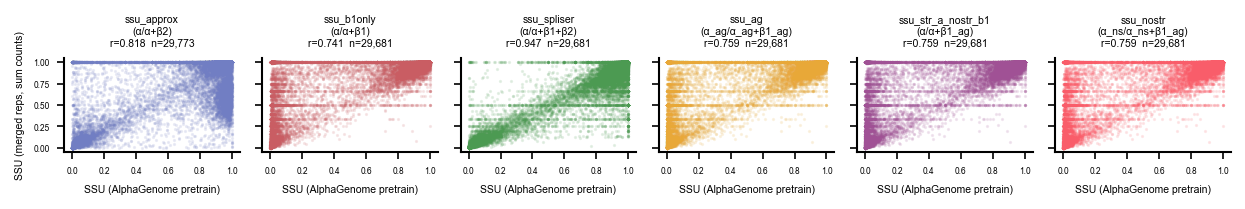

In [37]:
# Compare all SSU variants vs AlphaGenome pretrained SSU
# Variants tested:
#   ssu_approx         = alpha_juncs / (alpha_juncs + beta2_juncs)         junction-only
#   ssu_b1only         = alpha_bam   / (alpha_bam   + beta1_bam)           strand-specific b1
#   ssu_spliser        = alpha_bam   / (alpha_bam   + beta1_bam + beta2)   full SpliSER
#   ssu_ag             = alpha_ag    / (alpha_ag    + beta1_ag)            both counts strand-agnostic
#   ssu_str_a_nostr_b1 = alpha_bam   / (alpha_bam   + beta1_ag)            strand α, unstranded b1
#   ssu_nostr          = alpha_nostr / (alpha_nostr  + beta1_ag)           fully unstranded (pre majority-rule α)

ALL_AG_COUNT_COLS = ["alpha_juncs", "beta2_juncs",
                     "alpha_bam", "beta1_bam", "beta2_bam",
                     "alpha_ag", "beta1_ag",
                     "alpha_nostr"]

pipe_ag_parts = []
for sample, label in K562_SAMPLES.items():
    df = pd.read_parquet(
        os.path.join(K562_DIR, sample, "paper_pass.ssu.parquet"),
        columns=["chrom", "strand", "exon_pos"] + ALL_AG_COUNT_COLS,
    ).assign(sample=label)
    pipe_ag_parts.append(df)
pipe_ag = pd.concat(pipe_ag_parts, ignore_index=True)

# Merge replicates by summing all raw counts
merged_ag = pipe_ag.groupby(KEY, as_index=False)[ALL_AG_COUNT_COLS].sum()

# Recompute all SSU variants from summed counts
denom_approx        = merged_ag["alpha_juncs"] + merged_ag["beta2_juncs"]
denom_b1only        = merged_ag["alpha_bam"]   + merged_ag["beta1_bam"]
denom_spliser       = merged_ag["alpha_bam"]   + merged_ag["beta1_bam"] + merged_ag["beta2_bam"]
denom_ag            = merged_ag["alpha_ag"]    + merged_ag["beta1_ag"]
denom_str_nostr     = merged_ag["alpha_bam"]   + merged_ag["beta1_ag"]
denom_nostr         = merged_ag["alpha_nostr"] + merged_ag["beta1_ag"]

merged_ag["ssu_approx"]         = (merged_ag["alpha_juncs"] / denom_approx   ).where(denom_approx   > 0)
merged_ag["ssu_b1only"]         = (merged_ag["alpha_bam"]   / denom_b1only   ).where(denom_b1only   > 0)
merged_ag["ssu_spliser"]        = (merged_ag["alpha_bam"]   / denom_spliser  ).where(denom_spliser  > 0)
merged_ag["ssu_ag"]             = (merged_ag["alpha_ag"]    / denom_ag       ).where(denom_ag       > 0)
merged_ag["ssu_str_a_nostr_b1"] = (merged_ag["alpha_bam"]   / denom_str_nostr).where(denom_str_nostr> 0)
merged_ag["ssu_nostr"]          = (merged_ag["alpha_nostr"] / denom_nostr    ).where(denom_nostr    > 0)

# Check if unstranded counting gives more sites vs strand-specific
print("Sites (strand-specific ssu_spliser):    {:,}".format(merged_ag["ssu_spliser"].notna().sum()))
print("Sites (unstranded ssu_nostr):           {:,}".format(merged_ag["ssu_nostr"].notna().sum()))
print("Extra nostr sites not in spliser:       {:,}".format(
    (merged_ag["ssu_nostr"].notna() & merged_ag["ssu_spliser"].isna()).sum()))

# Join with pretrained SSU
merged_ag_pt = merged_ag.merge(pt_long[KEY + ["ssu_pretrain"]], on=KEY, how="inner")
print("\nMerged-replicate sites matching pretrained: {:,}".format(len(merged_ag_pt)))

VARIANTS_ALL = {
    "ssu_approx\n(α/α+β2)":           "ssu_approx",
    "ssu_b1only\n(α/α+β1)":           "ssu_b1only",
    "ssu_spliser\n(α/α+β1+β2)":       "ssu_spliser",
    "ssu_ag\n(α_ag/α_ag+β1_ag)":      "ssu_ag",
    "ssu_str_a_nostr_b1\n(α/α+β1_ag)":"ssu_str_a_nostr_b1",
    "ssu_nostr\n(α_ns/α_ns+β1_ag)":   "ssu_nostr",
}

# Correlation table
rows_all = []
for label, col in VARIANTS_ALL.items():
    valid = merged_ag_pt.dropna(subset=[col, "ssu_pretrain"])
    r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
    rows_all.append({"variant": col, "pearson_r": round(r, 4), "n": len(valid)})
print(pd.DataFrame(rows_all).to_string(index=False))

# Scatter panel
n_var = len(VARIANTS_ALL)
PAL_ALL = ["#717EC3", "#C95D63", "#4C9A52", "#E8A838", "#A05195", "#F95D6A"]
fig, axes = plt.subplots(1, n_var, figsize=(n_var * 3.5 * cm, 3.5 * cm),
                         sharex=True, sharey=True)

for ax, (label, col), color in zip(axes, VARIANTS_ALL.items(), PAL_ALL):
    valid = merged_ag_pt.dropna(subset=[col, "ssu_pretrain"])
    r, _ = pearsonr(valid[col], valid["ssu_pretrain"])
    ax.scatter(valid["ssu_pretrain"], valid[col],
               s=0.3, alpha=0.15, rasterized=True, color=color)
    ax.set_title("{}\nr={:.3f}  n={:,}".format(label, r, len(valid)), fontsize=5)
    ax.set_xlabel("SSU (AlphaGenome pretrain)", fontsize=5)
    ax.tick_params(labelsize=4)
    sns.despine(ax=ax)

axes[0].set_ylabel("SSU (merged reps, sum counts)", fontsize=5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "k562_ssu_all_variants_comparison.pdf"), bbox_inches="tight")
plt.show()

## Section 7: K562 pretraining SSU vs MEC1 finetuning samples (WT and SF3B1 K700E)

Cross-cell-type correlation: how similar are splice-site usage values between the K562 pretraining
data and the MEC1 samples used for finetuning?

- **K562 pretrained**: `pt_long` from Section 5 (VALID subset, ssu_approx equivalent)
- **MEC1 WT**: SRR17111303 (WT rep1)
- **MEC1 K700E**: SRR17111311 (SF3B1 K700E rep1)

Uses `ssu_approx = alpha_juncs / (alpha_juncs + beta2_juncs)` — the junction-only denominator
that matches what AlphaGenome is trained to predict.

Shared sites per sample (alpha_juncs >= 5):
sample
MEC1 SF3B1 K700E rep1    21199
MEC1 WT rep1             20868
Name: n_sites, dtype: int64


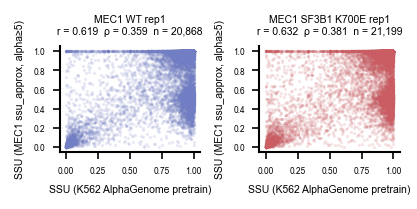

,sample,pearson_r,spearman_rho,n
0,MEC1 WT rep1,0.6187,0.3586,20868
1,MEC1 SF3B1 K700E rep1,0.6318,0.3814,21199


In [38]:
from scipy.stats import spearmanr

FINETUNE_SAMPLES = {
    "SRR17111303": "MEC1 WT rep1",
    "SRR17111311": "MEC1 SF3B1 K700E rep1",
}
PAL_MEC1 = {"MEC1 WT rep1": "#717EC3", "MEC1 SF3B1 K700E rep1": "#C95D63"}
MIN_ALPHA = 5

# pt_long is defined in Section 5: chrom, strand, exon_pos (1-based), ssu_pretrain
KEY = ["chrom", "strand", "exon_pos"]

ft_parts = []
for sample, label in FINETUNE_SAMPLES.items():
    df = pd.read_parquet(
        os.path.join(DATA_DIR, sample, "paper_pass.ssu.parquet"),
        columns=["chrom", "strand", "exon_pos", "alpha_juncs", "beta2_juncs", "ssu_approx"],
    )
    df = df[df["chrom"].str.match(r"^chr[0-9XY]+$")].copy()
    df["sample"] = label
    ft_parts.append(df)

ft = pd.concat(ft_parts, ignore_index=True)
merged7 = ft.merge(pt_long[KEY + ["ssu_pretrain"]], on=KEY, how="inner")
merged7 = merged7[merged7["alpha_juncs"] >= MIN_ALPHA]
print("Shared sites per sample (alpha_juncs >= {}):".format(MIN_ALPHA))
print(merged7.groupby("sample").size().rename("n_sites"))

# --- scatter: one panel per sample ---
samples7 = list(FINETUNE_SAMPLES.values())
fig, axes = plt.subplots(1, len(samples7), figsize=(len(samples7) * 3.5 * cm, 3.5 * cm))

rows7 = []
for ax, label in zip(axes, samples7):
    sub = merged7[merged7["sample"] == label].dropna(subset=["ssu_approx", "ssu_pretrain"])
    r, _  = pearsonr(sub["ssu_approx"], sub["ssu_pretrain"])
    rho, _ = spearmanr(sub["ssu_approx"], sub["ssu_pretrain"])
    rows7.append({"sample": label, "pearson_r": round(r, 4), "spearman_rho": round(rho, 4), "n": len(sub)})
    ax.scatter(sub["ssu_pretrain"], sub["ssu_approx"],
               s=0.3, alpha=0.15, rasterized=True, color=PAL_MEC1[label])
    ax.set_xlabel("SSU (K562 AlphaGenome pretrain)", fontsize=5)
    ax.set_ylabel("SSU (MEC1 ssu_approx, alpha≥{})".format(MIN_ALPHA), fontsize=5)
    ax.set_title("{}\nr = {:.3f}  ρ = {:.3f}  n = {:,}".format(label, r, rho, len(sub)), fontsize=5)
    ax.tick_params(labelsize=4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mec1_ssu_vs_k562_pretrain.pdf"), bbox_inches="tight")
plt.show()

pd.DataFrame(rows7)